# BEV deep dive

In [2]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
year = 2045

f = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs/"
run = "20260213-flex-weaker-low-flex-scenarios-pminpu0.5-49cl-1H" 
n = pypsa.Network(f"{f}{run}/Base/networks/base_s_49__none_{year}.nc")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Implementation structure
- Load "{busname} land transport EV" is attached to the bus ""{busname} EV battery" and has the carrier "land transport EV"; it has a time varying consumption profile
- 

## Load
- what exactly is the EV load? Is it a charging profile? Is it a current consunption/driving profile?
- is there a way to split it into a flexible and inflexible part? -> idea is to ex-post assign that part of BEV charging that is directly charged into the land transport EV load as inflexible and that one that is charged into the EV battery as flexible? Could also be done with the heat loads?

In [4]:
# Index of land transport EV load
ind_land_transport_ev = n.loads[(n.loads.carrier == "land transport EV") & n.loads.bus.str.startswith("DE")].index
n.loads.loc[ind_land_transport_ev].head(3)

,bus,carrier,type,p_set,q_set,sign,active
Load,,,,,,,
DE0 0 land transport EV,DE0 0 EV battery,land transport EV,,0.0,0.0,-1.0,True
DE0 1 land transport EV,DE0 1 EV battery,land transport EV,,0.0,0.0,-1.0,True
DE0 10 land transport EV,DE0 10 EV battery,land transport EV,,0.0,0.0,-1.0,True


In [5]:
# overall load in TWh (2035: 136 TWh; 2045: 185 TWh)
n.loads_t.p[ind_land_transport_ev].sum().sum() / 1e6

# land_transport_electric_share:
# 2025: 0.15
# 2035: 0.45
# 2045: 0.87

185.37436301781278

<Axes: xlabel='snapshot'>

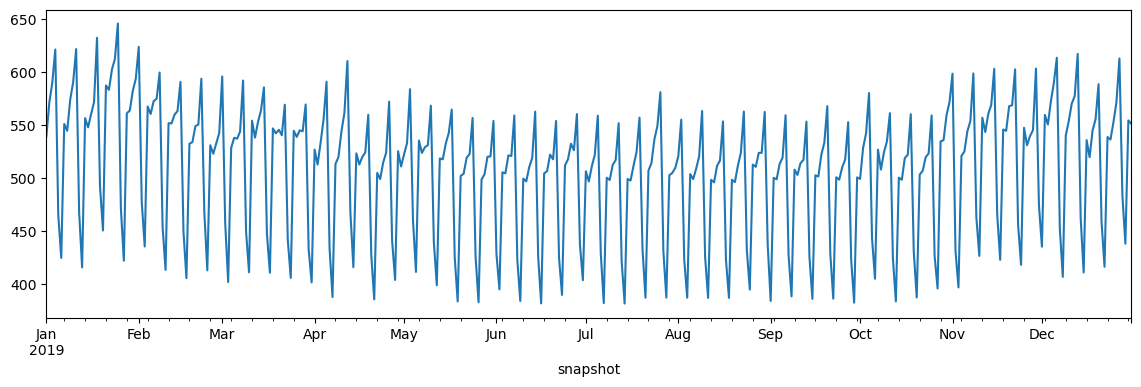

In [6]:
# EV consumption per day in GWh
(n.loads_t.p[ind_land_transport_ev].sum(axis=1).resample("D").sum()/1e3).plot(figsize=(14, 4), label="EV load profile (DE)")

<Axes: xlabel='snapshot'>

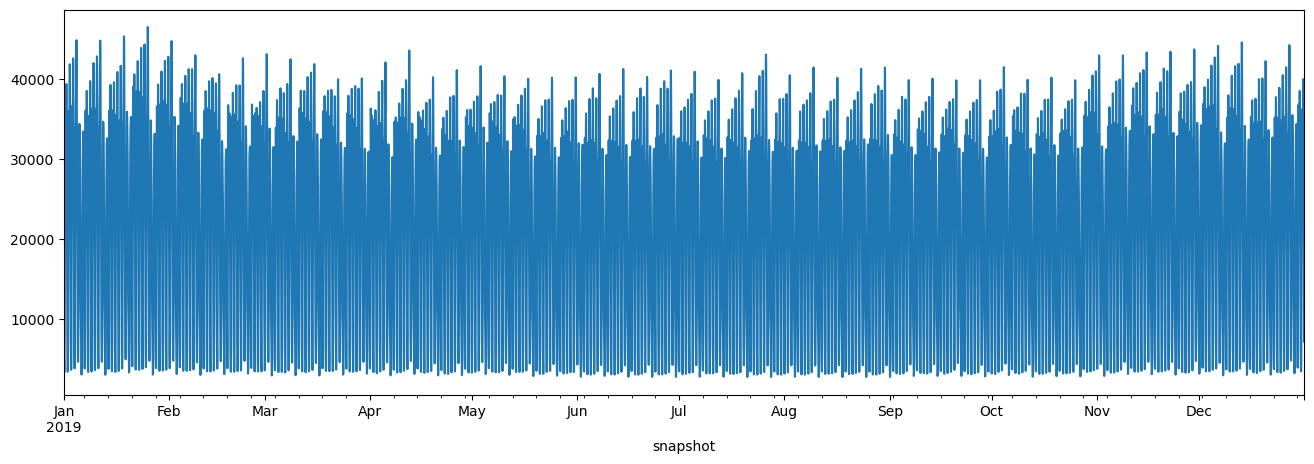

In [7]:
# Load consumption profile (aggregated)
n.loads_t.p[ind_land_transport_ev].sum(axis=1).plot(figsize=(16, 5))

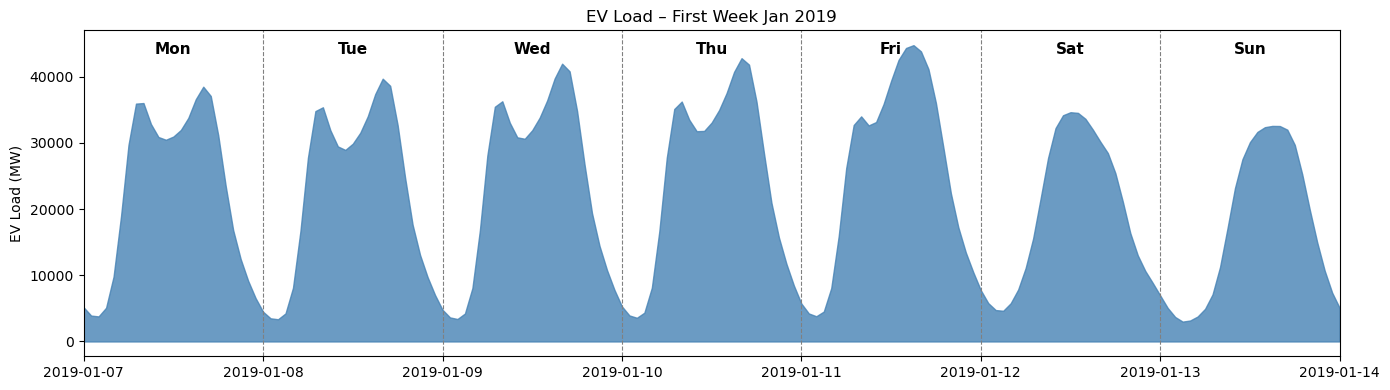

In [8]:
# Load profile for first week in January
ev_load = n.loads_t.p[ind_land_transport_ev].sum(axis=1)

# First Monday in Jan 2019
first_monday = ev_load['2019-01'].index[ev_load['2019-01'].index.dayofweek == 0][0]
week_data = ev_load[first_monday: first_monday + pd.Timedelta(days=7)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(week_data.index, week_data.values, color='steelblue', alpha=0.8)

# Day labels + separators
for i in range(7):
    day = first_monday + pd.Timedelta(days=i)
    if i > 0:
        ax.axvline(day, color='grey', linewidth=0.8, linestyle='--')
    ax.text(day + pd.Timedelta(hours=12), week_data.max() * 0.97,
            ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][i],
            ha='center', fontweight='bold', fontsize=11)

ax.set_xlim(week_data.index[0], week_data.index[-1])
ax.set_ylabel('EV Load (MW)')
ax.set_title('EV Load – First Week Jan 2019')
plt.tight_layout()
plt.show()

- EV load has a daily, weekly and annual pattern
- it seems like it is more a car consumption profile (timeseries when cars are driving) and not a charging profile (charging is likely to happen during the night)
- what is weird with the load is that it assumes EVs are being charged during driving; it calcs the charging load time series from actual traffic/driving data so it has to be served at the time of consumption (during the ride); this assumption is more unrealistic than flexible charging

## EV Land Transport Load Profile in PyPSA-Eur

**What it represents**

The load profile represents **km driven converted to electricity demand (MW)**, i.e. how much energy the EV fleet needs to actually move — not when they charge, but the underlying driving energy demand distributed over time.

**How it's calculated**

**1. Transport demand shape (`build_transport_demand`)**

A weekly traffic count profile (averaged over 2010–2015) is normalized and used to distribute annual transport energy demand across snapshots. The total annual energy is taken from `pop_weighted_energy_totals` (total road + rail - electric rail), giving a nodal **km-driven profile in units of 100 km**.

**2. ICE correction**

The shape is corrected for the fact that ICE vehicle energy totals include heating/cooling demand via `transport_degree_factor`. This is divided out so the underlying km-driven demand is heating-neutral.

**3. EV efficiency correction (`add_EVs`)**

The final load `p_set` on the EV battery bus is:

```
profile = electric_share × p_set / efficiency
```

where `efficiency` is the temperature-corrected EV efficiency (`transport_electric_efficiency` adjusted for heating/cooling via `get_temp_efficiency`) and further smoothed with a 3-hour rolling average (`cycling_shift`). The temperature correction goes the other way from ICE — EVs also consume more energy for heating/cooling, so efficiency drops in cold/hot weather.

**Key implication for DSM**

The load profile represents **actual driving energy demand by hour** — it cannot be shifted because cars must have energy available *when they drive*, not when it's convenient to charge. This is why the flexibility is on the **charging side** (BEV charger dispatch) and not on the load side, with the Store buffering between the two.


# Link: Charging

In [9]:
# Index of BEV charger
ind_charger = n.links[(n.links.carrier == "BEV charger") & n.links.bus0.str.startswith("DE")].index
n.links.loc[ind_charger].head(3)

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,dc,underwater_fraction,project_status,overnight_cost,location,energy to power ratio,reversed,length_original,retrofitted,fixed_profile_scaling_opt
Link,,,,,,,,,,,,,,,,,,,,,
DE0 0 BEV charger-2045,DE0 0 low voltage,DE0 0 EV battery,,BEV charger,0.9,True,2045,1.0,14913.316669,0.0,...,NaN,NaN,,NaN,,NaN,False,0.0,NaN,0.0
DE0 1 BEV charger-2045,DE0 1 low voltage,DE0 1 EV battery,,BEV charger,0.9,True,2045,1.0,15686.670345,0.0,...,NaN,NaN,,NaN,,NaN,False,0.0,NaN,0.0
DE0 10 BEV charger-2045,DE0 10 low voltage,DE0 10 EV battery,,BEV charger,0.9,True,2045,1.0,4673.564120,0.0,...,NaN,NaN,,NaN,,NaN,False,0.0,NaN,0.0


In [10]:
# total charging capacity in Germany in year
round(n.links.loc[ind_charger].p_nom_opt.sum() / 1e3, 2) # GW 

442.59

- BEV charger connect the low voltage bus with the EV battery bus; their carrier is "BEV charger"
- they have a charging efficiency of 0.9 which can be set in the config (bev_charge_efficiency: 0.9)
- p_nom is calculated as: `p_nom = number_cars × bev_charge_rate × electric_share` where bev_charge_rate is the power consumption for one electric vehicle (EV) in MWh. Value derived from 3-phase charger with 11 kW and electric share is the share of land transport that is electrified (can be set via config as sector:land_transport_electric_share)
- in 2025 in Germany there were about 50 Mio cars registered -> 50 Mio * 11KW * 100% = 550 GW of charging capacity if all are electrified
- the charging capacity is not always available: p_max_pu is set as a time series of possible charging times (times when EVs are plugged in) The BEV charger's `p_max_pu` is set to the availability profile, derived from traffic data with an inverse relationship: fewer cars on the road = more plugged in and available to charge. It scales between `bev_avail_mean` (0.8) and `bev_avail_max` (0.95), so charging capacity is never fully available nor fully zero — it's always a fraction of the installed `p_nom = number_cars × bev_charge_rate × electric_share`. The availability profile is calcualted in build_transport_demand with the function "def bev_availability_profile". It seems like the parameters `bev_avail_mean` and  `bev_avail_max` are very decisive. Why are they set like they are? Why is not just the normal profile being used? -> check calc of the profile maybe total fleet numbers ar enot available. 
- 


- is initialised in prepare_sector_network (# Add BEV chargers)

**Questions:**
- assumption of number of cars is coming from ALADIN for PyPSA-DE? 
- What are the assumed number of cars for the investment years and why?
- Is the charging efficiency of 0.9 making sense?
- If I understadn it right atm, it is implicitly assumed that all BEVs that are not driving have access to charging infrastructure? So the bev_avail_max of 0.95% is a number that says on avergae European street at the time of least traffic 95% of cars a re parked. And this is then directly used as a number for cars being available for charging?? THis should be much lower. 
- is 11kW a realistic assumption for the charger capacity?

In [11]:
# charger availability
n.links_t.p_max_pu[ind_charger].mean(axis=1).mean() # 80% average availability of chargers
n.links_t.p_max_pu[ind_charger].mean(axis=1).max() # 95% max availability of chargers

0.9499999999999995

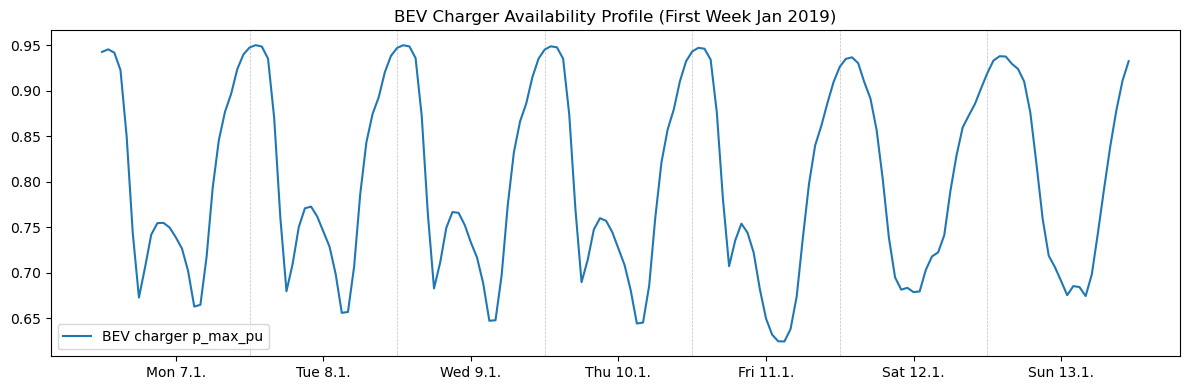

In [12]:
# BEC charger availability profile

fig, ax = plt.subplots(figsize=(12, 4))
data = n.links_t.p_max_pu[ind_charger].mean(axis=1)
first_monday = data.index[data.index.dayofweek == 0][0]
data = data[first_monday:][:24*7]

ax.plot(data.index, data.values, label="BEV charger p_max_pu")  # matplotlib directly, no auto-ticker

day_starts = data.index[::24]
for ts in day_starts[1:]:
    ax.axvline(ts, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

ax.set_xticks(day_starts + pd.Timedelta(hours=12))
ax.set_xticklabels([ts.strftime("%a %-d.%-m.") for ts in day_starts])
ax.set_xlabel("")
ax.legend()
plt.title("BEV Charger Availability Profile (First Week Jan 2019)")
plt.tight_layout()
plt.show()

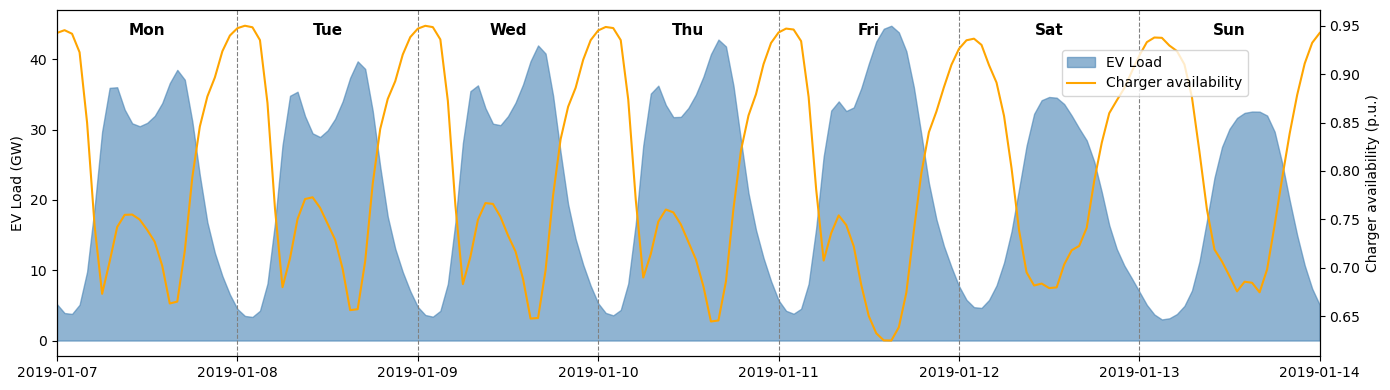

In [13]:
# EV load and charger availability profile

fig, ax1 = plt.subplots(figsize=(14, 4))

# EV load
ev_load = n.loads_t.p[ind_land_transport_ev].sum(axis=1)/1e3
first_monday = ev_load['2019-01'].index[ev_load['2019-01'].index.dayofweek == 0][0]
week_ev = ev_load[first_monday: first_monday + pd.Timedelta(days=7)]

ax1.fill_between(week_ev.index, week_ev.values, color='steelblue', alpha=0.6, label='EV Load')
ax1.set_ylabel('EV Load (GW)')

# Charging availability
ax2 = ax1.twinx()
week_charger = n.links_t.p_max_pu[ind_charger].mean(axis=1)[first_monday: first_monday + pd.Timedelta(days=7)]
ax2.plot(week_charger.index, week_charger.values, color='orange', linewidth=1.5, label='Charger availability')
ax2.set_ylabel('Charger availability (p.u.)')

# Day labels + separators
for i in range(7):
    day = first_monday + pd.Timedelta(days=i)
    if i > 0:
        ax1.axvline(day, color='grey', linewidth=0.8, linestyle='--')
    ax1.text(day + pd.Timedelta(hours=12), week_ev.max() * 0.97,
             ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][i],
             ha='center', fontweight='bold', fontsize=11)

ax1.set_xlim(week_ev.index[0], week_ev.index[-1])
ax1.set_xlabel('')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

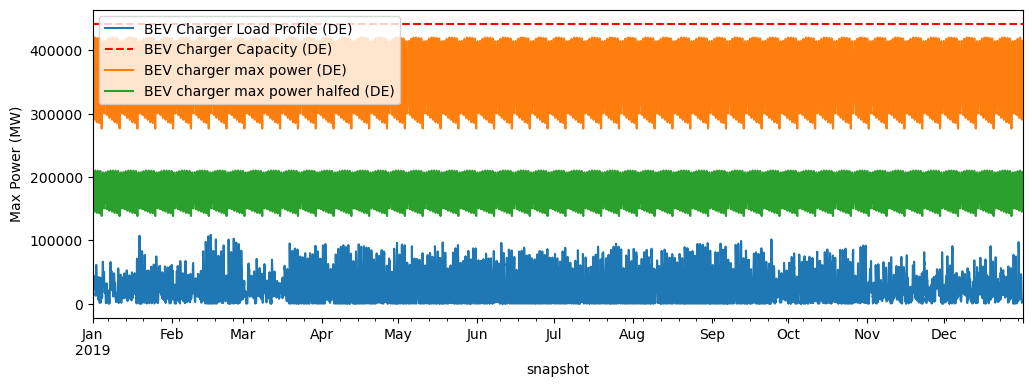

In [14]:
snapshots = 8760

fig, ax = plt.subplots(figsize=(12, 4))

n.links_t.p0[ind_charger].sum(axis=1)[:snapshots].plot(ax=ax, label="BEV Charger Load Profile (DE)", ylabel="Load (MW)")
ax.hlines(n.links.loc[ind_charger].p_nom_opt.sum(), xmin=n.links_t.p0[ind_charger].sum(axis=1)[:snapshots].index[0], xmax=n.links_t.p0[ind_charger].sum(axis=1)[:snapshots].index[-1], colors='r', linestyles='dashed', label="BEV Charger Capacity (DE)")
(n.links_t.p_max_pu[ind_charger] * n.links.loc[ind_charger].p_nom_opt).sum(axis=1)[:snapshots].plot(ax=ax, label="BEV charger max power (DE)", ylabel="Max Power (MW)")
(n.links_t.p_max_pu[ind_charger] * n.links.loc[ind_charger].p_nom_opt * 0.5).sum(axis=1)[:snapshots].plot(ax=ax, label="BEV charger max power halfed (DE)", ylabel="Max Power (MW)")

ax.legend()

- even if the availability profile was halfed it would not make a difference


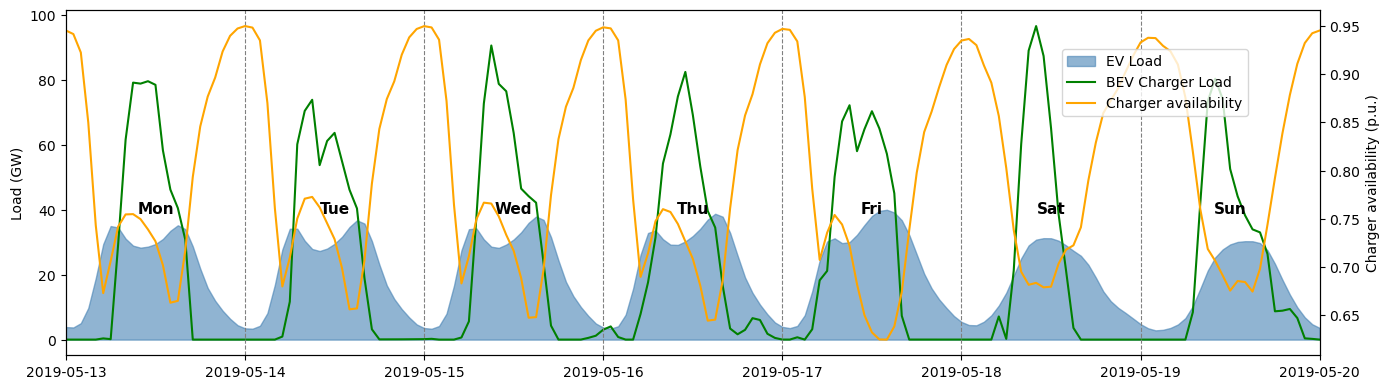

In [15]:
week_number = 20  # change this to any week 1-52

fig, ax1 = plt.subplots(figsize=(14, 4))

ev_load = n.loads_t.p[ind_land_transport_ev].sum(axis=1)/1e3
week_start = pd.Timestamp('2019-01-01') + pd.Timedelta(weeks=week_number - 1)
week_start -= pd.Timedelta(days=week_start.dayofweek)  # snap to Monday
week = slice(week_start, week_start + pd.Timedelta(days=7))

ax1.fill_between(ev_load[week].index, ev_load[week].values, color='steelblue', alpha=0.6, label='EV Load')
ax1.plot(n.links_t.p0[ind_charger].sum(axis=1)[week]/1e3, color='green', linewidth=1.5, label='BEV Charger Load')
ax1.set_ylabel('Load (GW)')

ax2 = ax1.twinx()
ax2.plot(n.links_t.p_max_pu[ind_charger].mean(axis=1)[week], color='orange', linewidth=1.5, label='Charger availability')
ax2.set_ylabel('Charger availability (p.u.)')

for i in range(7):
    day = week_start + pd.Timedelta(days=i)
    if i > 0:
        ax1.axvline(day, color='grey', linewidth=0.8, linestyle='--')
    ax1.text(day + pd.Timedelta(hours=12), ev_load[week].max() * 0.97,
             ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][i], ha='center', fontweight='bold', fontsize=11)

ax1.set_xlim(ev_load[week].index[0], ev_load[week].index[-1])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

# Store: BED_DSM

In [16]:
ind_stores = n.stores[(n.stores.carrier == "EV battery") & n.stores.bus.str.startswith("DE")].index
n.stores.loc[ind_stores].head(3)

,bus,type,carrier,e_nom,e_nom_mod,e_nom_extendable,e_nom_min,e_nom_max,e_min_pu,e_max_pu,...,marginal_cost_quadratic,marginal_cost_storage,capital_cost,standing_loss,active,build_year,lifetime,e_nom_opt,overnight_cost,location
Store,,,,,,,,,,,,,,,,,,,,,
DE0 0 EV battery,DE0 0 EV battery,,EV battery,33893.901520,0.0,False,0.0,inf,0.0,1.0,...,0.0,0.0,0.0,0.0,True,0,inf,33893.901520,NaN,
DE0 1 EV battery,DE0 1 EV battery,,EV battery,35651.523512,0.0,False,0.0,inf,0.0,1.0,...,0.0,0.0,0.0,0.0,True,0,inf,35651.523512,NaN,
DE0 10 EV battery,DE0 10 EV battery,,EV battery,10621.736637,0.0,False,0.0,inf,0.0,1.0,...,0.0,0.0,0.0,0.0,True,0,inf,10621.736637,NaN,


In [17]:
# storage capacity
n.stores.loc[ind_stores].e_nom_opt.sum() / 1e3 # GWh

1005.887625

In [18]:
# max load per day
n.stores_t.e[ind_stores].sum(axis=1).resample("D").sum().max() / 1e3 # GWh/day

23340.377296403472

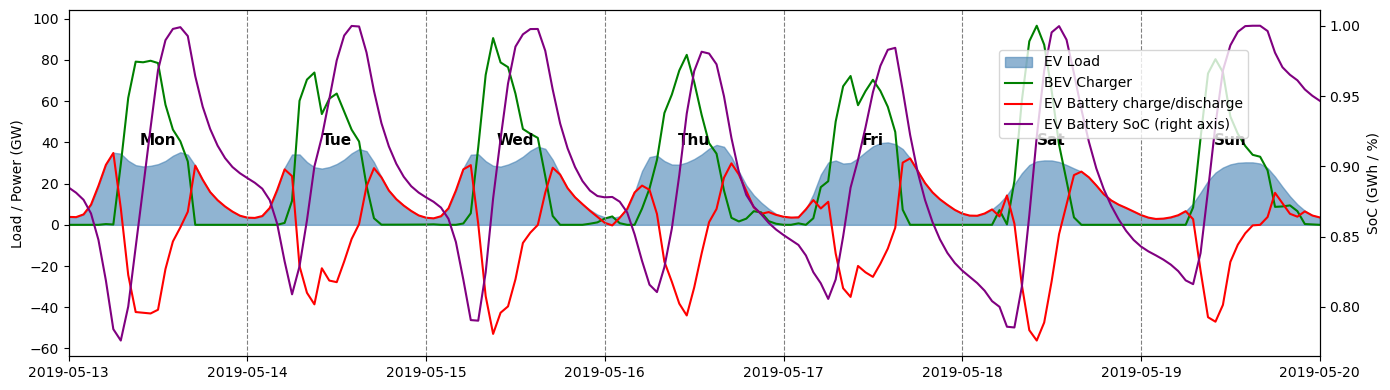

In [19]:
week_number = 20  # change this to any week 1-52

fig, ax1 = plt.subplots(figsize=(14, 4))

ev_load = n.loads_t.p[ind_land_transport_ev].sum(axis=1)/1e3
week_start = pd.Timestamp('2019-01-01') + pd.Timedelta(weeks=week_number - 1)
week_start -= pd.Timedelta(days=week_start.dayofweek)
week = slice(week_start, week_start + pd.Timedelta(days=7))

# Left axis: power flows
ax1.fill_between(ev_load[week].index, ev_load[week].values, color='steelblue', alpha=0.6, label='EV Load')
ax1.plot(n.links_t.p0[ind_charger].sum(axis=1)[week]/1e3, color='green', linewidth=1.5, label='BEV Charger')
ax1.plot(n.stores_t.p[ind_stores].sum(axis=1)[week]/1e3, color='red', linewidth=1.5, label='EV Battery charge/discharge')
# ax1.plot((n.links_t.p_max_pu[ind_charger] * n.links.loc[ind_charger].p_nom_opt).sum(axis=1)[week]/1e3,
#          color='orange', linewidth=1.5, label='Charger max power')
ax1.set_ylabel('Load / Power (GW)')

# Right axis: SoC
ax2 = ax1.twinx()
# ax2.plot(n.stores_t.e[ind_stores].sum(axis=1)[week]/1e3, color='purple', linewidth=1.5, label='EV Battery SoC') 
ax2.plot(n.stores_t.e[ind_stores].sum(axis=1)[week]/n.stores.loc[ind_stores].e_nom_opt.sum(), color='purple', linewidth=1.5, label='EV Battery SoC (right axis)') 
ax2.set_ylabel('SoC (GWh / %)')

for i in range(7):
    day = week_start + pd.Timedelta(days=i)
    if i > 0:
        ax1.axvline(day, color='grey', linewidth=0.8, linestyle='--')
    ax1.text(day + pd.Timedelta(hours=12), ev_load[week].max() * 0.97,
             ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][i], ha='center', fontweight='bold', fontsize=11)

ax1.set_xlim(ev_load[week].index[0], ev_load[week].index[-1])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

In [22]:
n.stores_t.p[ind_stores]

Store,DE0 0 EV battery,DE0 1 EV battery,DE0 10 EV battery,DE0 11 EV battery,DE0 12 EV battery,DE0 13 EV battery,DE0 14 EV battery,DE0 15 EV battery,DE0 16 EV battery,DE0 17 EV battery,...,DE0 27 EV battery,DE0 28 EV battery,DE0 29 EV battery,DE0 3 EV battery,DE0 4 EV battery,DE0 5 EV battery,DE0 6 EV battery,DE0 7 EV battery,DE0 8 EV battery,DE0 9 EV battery
snapshot,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,153.558715,168.231673,-629.945979,130.803923,53.040385,109.225486,-222.692391,150.522581,-874.299090,-2127.944244,...,-1234.495962,-670.098397,46.642498,214.854192,101.484999,-1564.029541,-1265.527262,163.606304,-48.747355,0.000786
2019-01-01 01:00:00,-236.142775,127.963399,-827.319520,99.322872,40.297732,82.665465,-2010.316819,114.286266,106.450548,-1407.178012,...,-1283.225520,107.910083,35.397996,163.246290,77.087415,-1358.138760,-1438.413925,124.322679,86.736981,0.478245
2019-01-01 02:00:00,-1733.094153,120.578305,-843.179879,93.510598,37.916236,-910.677586,-2345.249134,107.696787,99.631655,-2484.884385,...,-1295.748447,101.912407,33.315481,-993.758533,-1293.637372,-1370.651534,50.326781,116.936156,-1595.041871,175.449251
2019-01-01 03:00:00,-1810.261629,-909.235089,-795.262233,-1650.921783,47.889952,-1133.122588,-2260.916366,-1006.548512,-565.137327,-1763.357574,...,-1245.580335,127.088025,-777.554155,-2729.885278,-1247.918042,-1125.633522,-1463.893148,-1897.159407,-1523.717975,-175.567411
2019-01-01 04:00:00,-1614.085346,-526.673008,-714.833447,-1323.921256,-599.599658,-991.475305,-2065.479572,-2117.085984,240.765260,-1420.579033,...,-1095.973566,230.522332,-694.183447,248.672575,-1097.013995,-714.154337,-1343.848269,-1713.975882,-1332.864619,-0.227724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,831.723598,891.117661,262.760383,715.734664,288.461789,580.587089,1029.893031,810.167501,770.121364,1453.470250,...,541.619051,764.909995,253.299962,1174.023416,554.561644,-88.149086,388.967727,878.825006,622.979738,1329.158282
2019-12-31 20:00:00,595.776638,638.832424,187.725887,509.369709,205.437766,414.502423,736.331529,578.121619,548.903803,1036.229017,...,388.367579,546.065946,182.007106,834.254433,396.206592,-401.503960,276.639208,629.217050,444.963831,-363.965128
2019-12-31 21:00:00,443.364850,475.219388,139.095539,380.016153,151.914285,307.619129,546.501033,428.975896,406.366490,772.387771,...,287.710386,403.910517,134.941994,617.135906,293.299494,797.197619,205.225416,466.448138,329.957875,-1411.828288


In [20]:
n.stores_t.e[ind_stores].sum(axis=1)[week]/n.stores.loc[ind_stores].e_nom_opt.sum()

snapshot
2019-05-13 00:00:00    0.884885
2019-05-13 01:00:00    0.881165
2019-05-13 02:00:00    0.876137
2019-05-13 03:00:00    0.866443
2019-05-13 04:00:00    0.847640
                         ...   
2019-05-19 20:00:00    0.965109
2019-05-19 21:00:00    0.961178
2019-05-19 22:00:00    0.954703
2019-05-19 23:00:00    0.950205
2019-05-20 00:00:00    0.946635
Length: 169, dtype: float64

- store does not need to shift very much energy to the night because most of the load is happening during the day and can directyl be provided by cheap solar electricity
- in the energy balance the EV store can have a simulataneous cahrge and discahrge in a timestep ( in fact it will almost always have) because the can be charging / discharging at every bus

In [21]:
n.stores_t.e

Store,AT0 0 EV battery,AT0 0 H2 Store-2045,AT0 0 battery-2045,AT0 0 co2 sequestered-2045,AT0 0 co2 stored,AT0 0 home battery-2035,AT0 0 home battery-2045,AT0 0 non-sequestered HVC,AT0 0 rural water tanks-2025,AT0 0 rural water tanks-2035,...,SE1 0 rural water tanks-2045,SE1 0 urban central water pits-2025,SE1 0 urban central water pits-2035,SE1 0 urban central water pits-2045,SE1 0 urban central water tanks-2025,SE1 0 urban central water tanks-2035,SE1 0 urban central water tanks-2045,SE1 0 urban decentral water tanks-2025,SE1 0 urban decentral water tanks-2045,co2 atmosphere
snapshot,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,88376.737845,0.047714,3453.083830,0.0,0.302363,1705.902189,0.035904,2.599847e+06,0.039744,0.034026,...,0.027728,389414.068905,179.561631,6883.219103,10.335931,7.417775,2.658142,0.022924,0.012101,2.233879e+04
2019-01-01 01:00:00,91042.919941,0.048844,3445.913577,0.0,0.302415,1698.480540,0.036034,2.598991e+06,0.040548,0.034458,...,0.027225,392064.760143,179.563779,6891.022209,10.334066,7.416475,2.658284,0.023420,0.012493,4.516336e+04
2019-01-01 02:00:00,90699.900716,0.047615,2818.728513,0.0,0.302398,1342.566076,0.036230,2.598135e+06,488.386876,439.565229,...,0.025803,394489.628232,179.565841,6899.547745,10.332452,7.415351,2.658384,0.023565,0.012325,6.812841e+04
2019-01-01 03:00:00,90256.367114,0.050065,1839.423662,0.0,0.302304,887.368072,0.036258,2.597278e+06,598.618201,1056.605502,...,0.050924,396215.165897,179.567380,6906.628767,10.331085,7.414399,2.658451,0.023625,0.012213,9.167089e+04
2019-01-01 04:00:00,89408.681252,0.052029,860.136140,0.0,0.302182,432.187179,0.036463,2.596422e+06,538.497927,765.402415,...,0.017127,396775.714077,179.567636,6908.002917,10.330006,7.413647,2.658383,0.023250,0.012147,1.179249e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,89688.066931,0.050054,4588.654612,0.0,0.302961,2668.673272,0.035662,3.424968e+03,0.000206,0.000167,...,0.034102,378072.306411,169.816793,6867.094516,10.348287,7.426398,2.658094,297.915474,0.017033,1.900662e+08
2019-12-31 20:00:00,87855.473124,0.049816,3919.093270,0.0,0.302833,2316.886928,0.035679,2.568726e+03,0.047194,0.038498,...,0.000394,379511.817207,169.455275,6873.915697,10.345468,7.424429,2.657924,421.626867,0.016967,1.900965e+08
2019-12-31 21:00:00,86497.220874,0.050025,3597.389776,0.0,0.302691,1997.714635,0.035724,1.712484e+03,0.040496,0.033548,...,0.035292,381483.453125,169.138833,6882.710273,10.342829,7.422587,2.657835,565.453029,0.016767,1.901257e+08


# BEV DSM & V2G Implementation in PyPSA-Eur / PyPSA-DE

The implementation models flexible EV charging through a **Bus → BEV Charger Link → EV Battery Store → EV Load** chain.

## Availability & Charging Capacity

The BEV charger's `p_max_pu` is set to the availability profile, derived from traffic data with an inverse relationship: fewer cars on the road = more plugged in and available to charge. It scales between `bev_avail_mean` (0.8) and `bev_avail_max` (0.95), so charging capacity is never fully available nor fully zero — it's always a fraction of the installed `p_nom = number_cars × bev_charge_rate × electric_share`.

## DSM (`bev_dsm`)

When enabled, an EV battery `Store` is added with `e_cyclic=True` and capacity `e_nom = number_cars × bev_energy × bev_dsm_availability × electric_share`. Only the fraction `bev_dsm_availability` (default 0.5) of cars participates in flexible charging — the other half is implicitly assumed to charge inflexibly (though technically the load is not split; the reduced `e_nom` simply limits the available flexibility buffer). The `e_min_pu` is set to the DSM profile, which enforces a minimum SoC of `bev_dsm_restriction_value` (0.8) at `bev_dsm_restriction_time` (7am) each day — ensuring cars are sufficiently charged for the morning commute. The optimizer can otherwise freely shift charging within these bounds, leading to opportunistic bulk charging during low-price or high-availability periods.

## V2G (`v2g`)

When enabled, a reverse Link (EV battery → grid bus) is added with `p_max_pu=avail_profile`, so discharge to the grid is only possible when cars are plugged in. Its `p_nom` is also scaled by `bev_dsm_availability`, consistent with only the DSM-participating fleet being capable of V2G.

## Key PyPSA Attributes Affected

| Component | Attribute | Role |
|---|---|---|
| BEV charger Link | `p_max_pu` | Limits charging to plugged-in share |
| EV battery Store | `e_nom` | Scales with DSM-participating share |
| EV battery Store | `e_min_pu` | Enforces 80% SoC by 7am daily |
| EV battery Store | `e_cyclic` | Ensures periodic consistency |
| V2G Link | `p_max_pu` | Mirrors charger availability |

# Q & A

**Could you briefly describe how the flexibility of EVs and heat is implemented? I've looked into the repository and identified build_transport_demand and build_hourly_heat_demand as two key rules to build the profiles. However I haven't fully understood how these profiles are eventually implemented.**
They are implemented differently. The flexible charging of EVs is implemented as a load that has to be met over time and not at every timestep. However there are some restrictions on state of charge etc. Heat demand has to be met at the time and place. Flexibility emerges from heat and other stores and the possibility to electrify heat demand as well as sector coupling.

**At least for BEVs, you also seem to be using a Store to model flexibility, right? Or does the store have a physical meaning in this case? Could you explain how this works and how avail_profile and dsm_profile interact in the add_EVs rule?**
The store represents the batteries of the aggregated EVs. Avail_profile defines when EVs can be charged (are plugged in) and dsm_profile represents the total electricity demand from BEVs. It sets the total energy requirement that must be met over time. Then you can specify bev_dsm_restriction _value which adds a lower state of charge for the BEV and bev_dsm_restriction _time to add a time when this state of charge has to be met. We say per default the BEVs have to be charged 75 % at 7 am in the morning to simulate "normal behaviour". However, the BEVs implementation is rather simple atm.
